In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# هذه الطريقة تجعل الكود ذكياً ويعرف المسار الصحيح مهما كان نظام التشغيل
file_path = os.path.join("..", "data", "diabetes.csv")
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
df = pd.read_csv(file_path, names=column_names)

# عرض أول 5 أسطر للتأكد من أن البيانات تم تحميلها بنجاح
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# عرض ملخص إحصائي سريع لجميع البيانات
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


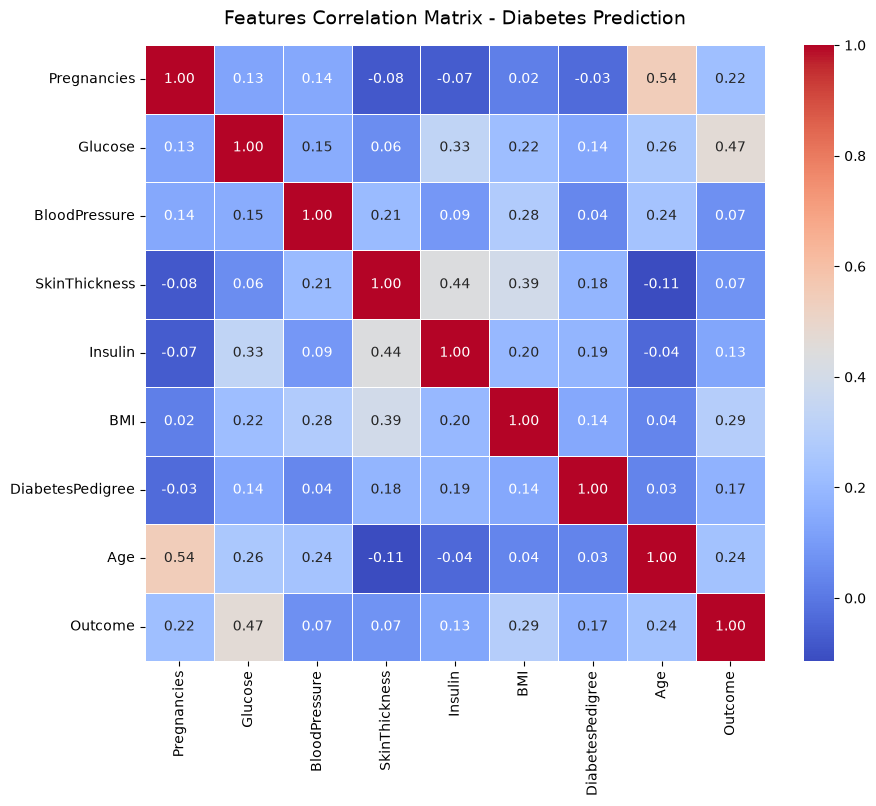

In [4]:
# رسم مصفوفة الارتباط (Correlation Matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Features Correlation Matrix - Diabetes Prediction', fontsize=14, pad=15)

# حفظ الصورة في المجلد لتكون جاهزة لاحقاً
plt.savefig('../reports/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# فصل المدخلات (المؤشرات) عن المخرجات (النتيجة)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"حجم بيانات التدريب: {X_train.shape[0]} مريض")
print(f"حجم بيانات الاختبار: {X_test.shape[0]} مريض")

حجم بيانات التدريب: 614 مريض
حجم بيانات الاختبار: 154 مريض


In [6]:
# بناء النموذج الأولي (Baseline Model) وتدريبه
model_v1 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v1.fit(X_train, y_train)

# توقع النتائج لبيانات الاختبار
predictions_v1 = model_v1.predict(X_test)

# حساب وطباعة الدقة
accuracy_v1 = accuracy_score(y_test, predictions_v1)
print(f"🎯 دقة النموذج الأولي (قبل تنظيف الأصفار): {accuracy_v1 * 100:.2f}%")

🎯 دقة النموذج الأولي (قبل تنظيف الأصفار): 72.08%


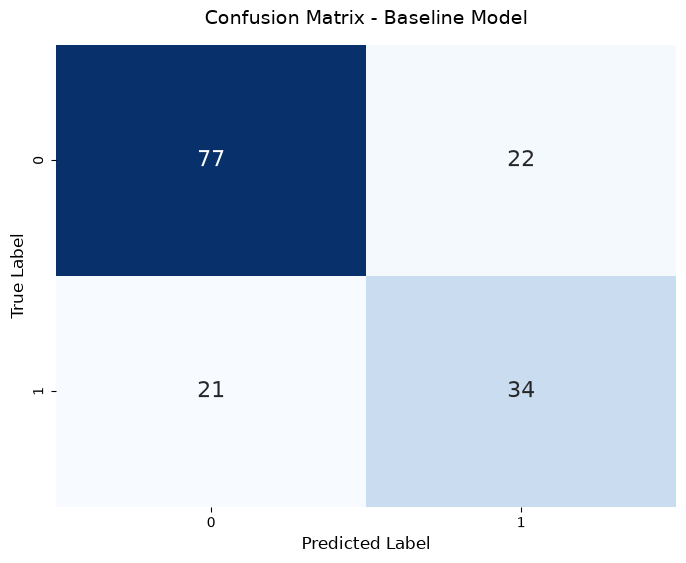

In [7]:
# رسم مصفوفة الارتباك لمعرفة تفاصيل الأخطاء والإصابات
cm_v1 = confusion_matrix(y_test, predictions_v1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_v1, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16})
plt.title('Confusion Matrix - Baseline Model', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.savefig('../reports/confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
import numpy as np

# 1. أخذ نسخة من البيانات للعمل عليها (حتى لا نلغي الجدول القديم)
df_cleaned = df.copy()

# 2. تحديد الأعمدة التي سنعالج أصفارها (لن نلمس عمود الحمل)
cols_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 3. استبدال الصفر بـ (NaN) ثم استبداله فوراً بالوسيط الحسابي للعمود
for col in cols_to_clean:
    df_cleaned[col] = df_cleaned[col].replace(0, np.nan)
    median_val = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(median_val)

# 4. إعادة فصل وتقسيم البيانات (النظيفة هذه المرة)
X_clean = df_cleaned.drop('Outcome', axis=1)
y_clean = df_cleaned['Outcome']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# 5. بناء النموذج المحسن (Optimized Model) وتدريبه
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train_c, y_train_c)

# 6. توقع النتائج وحساب الدقة الجديدة
predictions_v2 = model_v2.predict(X_test_c)
accuracy_v2 = accuracy_score(y_test_c, predictions_v2)

print(f"🚀 دقة النموذج المحسن (بعد تنظيف الأصفار): {accuracy_v2 * 100:.2f}%")

🚀 دقة النموذج المحسن (بعد تنظيف الأصفار): 74.68%


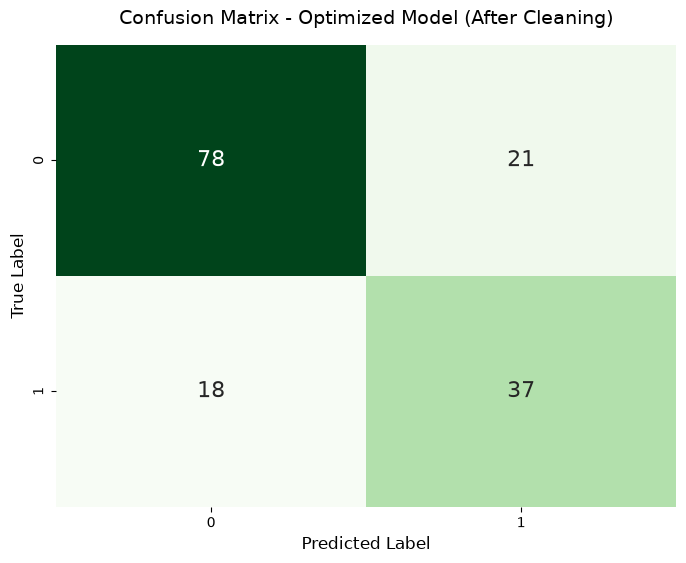

In [9]:
# رسم مصفوفة الارتباك للنموذج المحسن لمعرفة تفاصيل الأخطاء
cm_v2 = confusion_matrix(y_test_c, predictions_v2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_v2, annot=True, fmt="d", cmap="Greens", cbar=False, annot_kws={"size": 16})
plt.title('Confusion Matrix - Optimized Model (After Cleaning)', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# حفظ الصورة
plt.savefig('../reports/confusion_matrix_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# اختبار النموذج على مريض افتراضي
import pandas as pd

def predict_patient_status(data):
    # ترتيب الأعمدة يجب أن يطابق تماماً ترتيب بيانات التدريب
    features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
    
    # تحويل المدخلات إلى DataFrame ليعرف الموديل كل قيمة لأي ميزة تنتمي
    patient_df = pd.DataFrame([data], columns=features)
    
    # التنبؤ
    prediction = model_v2.predict(patient_df)
    probability = model_v2.predict_proba(patient_df) # لمعرفة نسبة الثقة في القرار
    
    # عرض النتيجة
    result = "مصابة بالسكري" if prediction[0] == 1 else "سليمة"
    conf = probability[0][prediction[0]] * 100
    
    print(f"--- نتيجة التشخيص ---")
    print(f"الحالة المتوقعة: {result}")
    print(f"نسبة الثقة في هذا القرار: {conf:.2f}%")

# ==========================================
# اختبري الآن! أدخلي بيانات مريضة افتراضية هنا
# الترتيب: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigree, Age]
# ==========================================
sample_patient = [1, 148, 72, 35, 79, 33.6, 0.627, 50] 

predict_patient_status(sample_patient)

--- نتيجة التشخيص ---
الحالة المتوقعة: مصابة بالسكري
نسبة الثقة في هذا القرار: 56.00%


In [11]:
import joblib

# حفظ النموذج في ملف
filename = '../models/diabetes_v1_female.joblib'
joblib.dump(model_v2, filename)

print(f"تم حفظ النموذج بنجاح في ملف: {filename}")

تم حفظ النموذج بنجاح في ملف: ../models/diabetes_v1_female.joblib
